In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

In [10]:
df = pd.read_csv(r'C:\Users\Asus user\Downloads\insurance.csv')
df.head()
insurance_data_path = 'insurance.csv'
insurance = pd.read_csv(insurance_data_path)
insurance.head()


,age,sex,bmi,children,smoker,region,charges
0,19.0,female,27.900,0.0,yes,southwest,16884.924
1,18.0,male,33.770,1.0,no,Southeast,1725.5523
2,28.0,male,33.000,3.0,no,southeast,$4449.462
3,33.0,male,22.705,0.0,no,northwest,$21984.47061
4,32.0,male,28.880,0.0,no,northwest,$3866.8552


In [6]:
## 1:clean up the data
### if there are any missing values,standardize categories in region, standardize charges in data type(float)

In [44]:
insurance_filled = insurance.dropna().copy()
insurance_filled['region'] = insurance_filled['region'].str.lower()
FEMALE = 'female'
MALE = 'male'
sex_map = {'F': FEMALE, 'woman': FEMALE, 'man' :MALE, 'M':MALE}
insurance_filled['sex']=insurance_filled['sex'].replace(sex_map)
insurance_filled['smoker'] = (insurance_filled['smoker']=='yes')
insurance_filled['charges'] = insurance_filled['charges'].str.strip('$').astype('float64')
insurance_filled = insurance_filled.copy()

insurance_filled['age'] = (
    insurance_filled['age']
        .astype(str)                     # force string
        .str.replace('–', '-', regex=False)  # fix en-dash
        .str.replace('−', '-', regex=False)  # fix minus symbol
        .str.strip()
)

insurance_filled['age'] = pd.to_numeric(insurance_filled['age'], errors='coerce').abs()


insurance_filled['children'] = insurance_filled['children'].abs()


insurance_filled.sample(20) 


,age,sex,bmi,children,smoker,region,charges
802,21.0,male,22.300,1.0,False,southwest,2103.08000
1136,44.0,female,25.000,1.0,False,southwest,7623.51800
81,45.0,female,38.285,0.0,False,northeast,7935.29115
314,27.0,female,31.400,0.0,True,southwest,34838.87300
591,47.0,male,19.570,1.0,False,northwest,8428.06930
472,19.0,female,29.800,0.0,False,southwest,1744.46500
1303,43.0,male,27.800,0.0,True,southwest,37829.72420
118,49.0,female,27.170,0.0,False,southeast,8601.32930
895,61.0,female,44.000,0.0,False,southwest,13063.88300
872,42.0,male,24.860,0.0,False,southeast,5966.88740


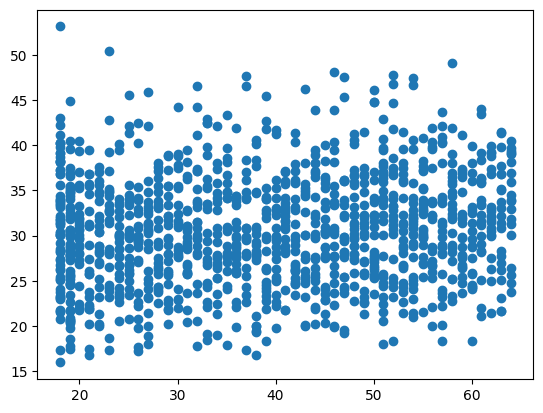

In [54]:
import matplotlib.pyplot as plt
df = insurance_pos.copy()
plt.scatter(df['age'], df['bmi'])
# 2: scatter plots of relationship between variables and charges

In [62]:
### 3 prepare data for model fitting
df_new = pd.get_dummies(df, prefix=['region'], columns=['region'])
df_new=df_new.drop(columns=['region_southeast'])
df_new['smoker']=df_new['smoker'].astype('int64')
df_new['sex']=(df_new['sex']=='male').astype('int64')
df_new=df_new.drop(columns=['sex'])
df_new.head()

,age,bmi,children,smoker,charges,region_northeast,region_northwest,region_southwest
0,19.0,27.900,0.0,1,16884.92400,False,False,True
1,18.0,33.770,1.0,0,1725.55230,False,False,False
2,28.0,33.000,3.0,0,4449.46200,False,False,False
3,33.0,22.705,0.0,0,21984.47061,False,True,False
4,32.0,28.880,0.0,0,3866.85520,False,True,False


In [93]:
# 1. Remove rows where target (charges) is missing
df_new = df_new.dropna(subset=['charges'])

# 2. Convert categorical columns to numeric
df_new = pd.get_dummies(df_new, drop_first=True)

# 3. Define X and y
X = df_new.drop(columns=['charges'])
y = df_new['charges']

# 4. Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Train Linear Regression model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

# 6. Predict and evaluate
from sklearn.metrics import r2_score
y_pred = model.predict(X_test)
r2_score = r2_score(y_test, y_pred)

print("R2 score:", r2)


R2 score: 0.7050490799809981


In [84]:
def preprocess_df(df):
    df_new = pd.get_dummies(df, prefix=['region'], columns=['region'])
    df_new=df_new.drop(columns=['region_southeast'])

    df_new['smoker'] = (df_new['smoker']=='yes')
    df_new['smoker']=df_new['smoker'].astype('int64')
    
    df_new['is_male']=(df_new['sex']=='male').astype('int64')
    df_new=df_new.drop(columns=['sex'])
    return df_new

In [94]:
# load validation data
val_df = pd.read_csv('https://raw.githubusercontent.com/KeithGalli/Regression-Example/refs/heads/master/validation_dataset.csv')

# apply SAME encoding
val_df = pd.get_dummies(val_df, drop_first=True)

# align columns with training data
val_df = val_df.reindex(columns=X.columns, fill_value=0)

# predict
predictions = model.predict(val_df)

# fix negative predictions if required
predictions_new = [x if x > 0 else 1000 for x in predictions]
validation_data = val_df.copy()
validation_data['predicted_charges']=predictions
validation_data.loc[validation_data['predicted_charges']<1000, 'predicted_charges']=1000
#validation_data['predicted_charges']=predictions_new
validation_data




,age,bmi,children,smoker,region_northeast,region_northwest,region_southwest,predicted_charges
0,18.0,24.090000,1.0,0,0,False,False,1000.000000
1,39.0,26.410000,0.0,0,0,False,False,6328.059124
2,27.0,29.150000,0.0,0,0,False,False,3946.312353
3,71.0,65.502135,13.0,0,0,False,False,31643.502071
4,28.0,38.060000,0.0,0,0,False,False,7043.916786
5,70.0,72.958351,11.0,0,0,False,False,33085.113671
6,29.0,32.110000,2.0,0,0,True,False,6799.230187
7,42.0,41.325000,1.0,0,0,False,False,12199.050811
8,48.0,36.575000,0.0,0,0,True,False,12710.229849
9,63.0,33.660000,3.0,0,0,False,False,16109.550096


In [88]:
import numpy as np

predictions_new = np.where(predictions > 0, predictions, 1000)


In [89]:
results_df = val_df.copy()
results_df['predicted_charges'] = predictions_new
results_df.head(10)


,age,bmi,children,smoker,region_northeast,region_northwest,region_southwest,predicted_charges
0,18.0,24.090000,1.0,0,0,False,False,229.250152
1,39.0,26.410000,0.0,0,0,False,False,6328.059124
2,27.0,29.150000,0.0,0,0,False,False,3946.312353
3,71.0,65.502135,13.0,0,0,False,False,31643.502071
4,28.0,38.060000,0.0,0,0,False,False,7043.916786
5,70.0,72.958351,11.0,0,0,False,False,33085.113671
6,29.0,32.110000,2.0,0,0,True,False,6799.230187
7,42.0,41.325000,1.0,0,0,False,False,12199.050811
8,48.0,36.575000,0.0,0,0,True,False,12710.229849
9,63.0,33.660000,3.0,0,0,False,False,16109.550096
